# Support Vector Machines (SVM) — Theory, Implementation & Evaluation


## 1. What is a Support Vector Machine?

We learned Logistic Regression — a classifier that finds a decision boundary by modeling the probability of class membership. Today we learn a fundamentally different approach: **Support Vector Machines (SVM)**.

The core idea of SVM is geometrically elegant: instead of thinking about probabilities, SVM asks a simple question — *"What is the best line (or hyperplane) that separates the two classes?"*

But what makes one separating line better than another? Imagine you have two clusters of points on a page — red and blue. You could draw many different lines between them. SVM picks the line that has the **maximum margin** — the greatest possible distance between the line and the nearest points of each class.

### Why Maximum Margin?

Think of it this way: if the decision boundary is far from both classes, it has more "breathing room." A new data point that falls slightly on one side is more likely to be classified correctly because the boundary is not hugging either class too closely. A boundary with a narrow margin is fragile — even a tiny shift in the data could cause misclassifications.

This is why SVM is sometimes called a **maximum margin classifier**.

### Key Terminology

Before we go further, let us define some terms that will come up repeatedly:

- **Hyperplane** — The decision boundary. In 2D, it is a line. In 3D, it is a plane. In higher dimensions, it is called a hyperplane. It is the surface that separates the two classes.

- **Margin** — The distance between the hyperplane and the nearest data points from each class. SVM maximizes this margin.

- **Support Vectors** — The data points that are closest to the hyperplane. These are the critical points — they "support" the hyperplane. If you removed any non-support-vector point, the hyperplane would not change. But if you moved a support vector, the entire boundary could shift. The model's decision boundary is entirely determined by these few points.

- **C (Regularization parameter)** — Controls the trade-off between having a wide margin and correctly classifying training points. We will explore this in detail later.

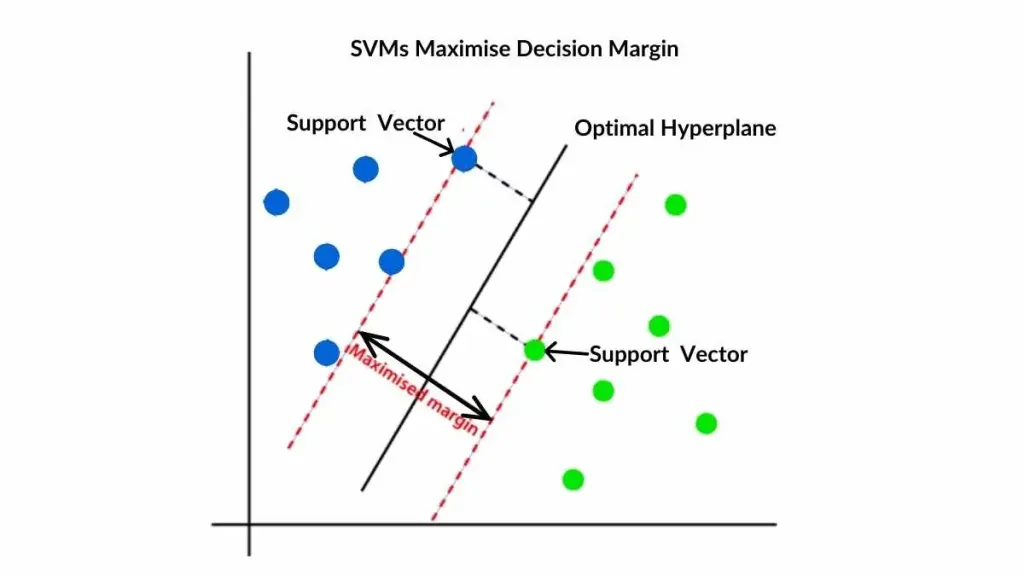

## 2. Hard Margin vs Soft Margin

### Hard Margin SVM

In a perfect world, the two classes are completely separable — no overlap, no noise. In this case, SVM finds a hyperplane that perfectly separates all points with maximum margin. This is called **hard margin** SVM.

The problem? Real-world data is almost never perfectly separable. There is always noise, outliers, and overlap. If we insist on a hard margin (zero tolerance for misclassification), either:
- No solution exists (the data cannot be linearly separated), or
- The margin becomes extremely narrow to accommodate outliers, leading to overfitting

### Soft Margin SVM

To handle real-world data, we relax the constraint and allow some points to be on the wrong side of the margin or even the wrong side of the boundary. This is **soft margin** SVM.

The parameter **C** controls how much we penalize these violations:

- **Large C** (e.g., 100) — Heavy penalty for misclassifications. The model tries very hard to classify every training point correctly, even if it means a narrow margin. Risk: **overfitting**.

- **Small C** (e.g., 0.01) — Light penalty for misclassifications. The model accepts some errors in exchange for a wider, more robust margin. Risk: **underfitting**.

Notice that C in SVM works the same way as C in Logistic Regression (Day 49) — **small C = strong regularization, large C = weak regularization**.

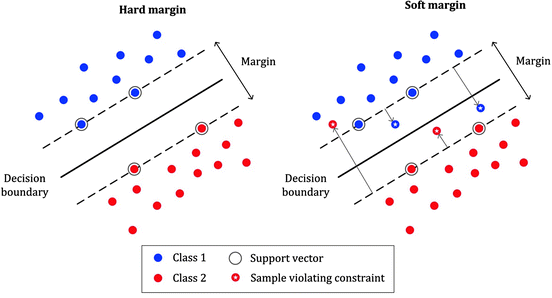

## 3. The Kernel Trick — Handling Non-Linear Data

What if the data is not linearly separable at all? Imagine two classes arranged in concentric circles — no straight line can separate them.

SVM has an elegant solution: the **kernel trick**. The idea is to **transform the data into a higher-dimensional space** where it becomes linearly separable, and then find the hyperplane in that space.

For example, 2D data that forms concentric circles can be mapped to 3D by adding a new feature $z = x^2 + y^2$. In 3D, the circles become separable by a flat plane. The kernel trick does this transformation implicitly — without actually computing the coordinates in the higher-dimensional space — which makes it computationally efficient.

### Common Kernels

- **Linear kernel** (`kernel='linear'`) — No transformation. Finds a straight hyperplane. Use when data is linearly separable or when you have many features.

- **RBF (Radial Basis Function) kernel** (`kernel='rbf'`) — The default and most popular. Maps data into infinite-dimensional space. Can handle complex, non-linear boundaries. Has a parameter **gamma** that controls how far the influence of a single training point reaches.

- **Polynomial kernel** (`kernel='poly'`) — Maps data using polynomial transformations. Has a **degree** parameter. Degree 2 gives quadratic boundaries, degree 3 gives cubic, and so on.

### The Gamma Parameter (for RBF kernel)

Gamma defines how much influence a single training example has:

- **Large gamma** — Each point has a small radius of influence. The decision boundary becomes very wiggly, tightly hugging individual points. Risk: **overfitting**.

- **Small gamma** — Each point has a large radius of influence. The decision boundary is smoother and more general. Risk: **underfitting**.

Together, **C** and **gamma** are the two most important hyperparameters for an RBF SVM.

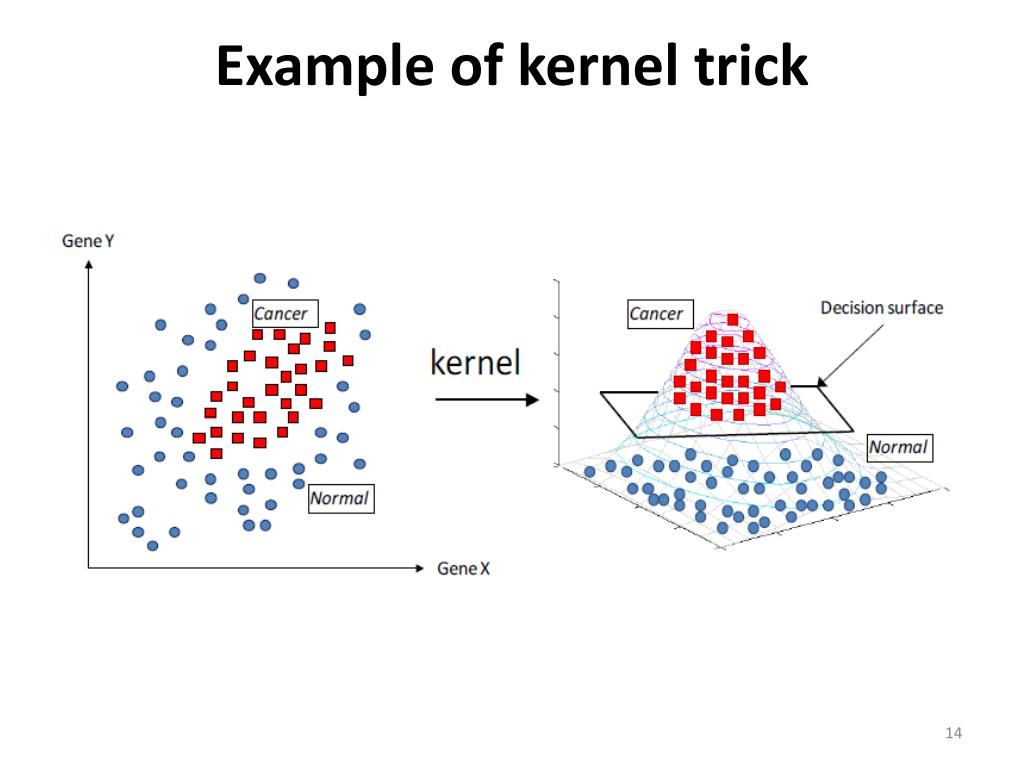

## 4. SVM vs Logistic Regression — When to Use What?

Both SVM and Logistic Regression are linear classifiers (in their basic forms). Here is a practical guide:

| Aspect | Logistic Regression | SVM |
|--------|--------------------|---------|
| **Output** | Probabilities (0 to 1) | Class labels (no probabilities by default) |
| **Decision Boundary** | Based on probability threshold | Based on maximum margin |
| **Non-linear data** | Needs manual feature engineering | Kernel trick handles it |
| **Many features, few samples** | Works but may overfit | SVM often excels here |
| **Large datasets** | Scales well | Can be slow (especially RBF kernel) |
| **Interpretability** | Coefficients are interpretable | Less interpretable (especially with kernels) |
| **Regularization** | C parameter (inverse of alpha) | C parameter (same meaning) |

**Rule of thumb:** Start with Logistic Regression (simpler, faster, interpretable). If it is not performing well and you suspect non-linear relationships, try SVM with an RBF kernel.

## 5. Setup and Imports

Let us import everything we need. We will use SVC (Support Vector Classifier) from Scikit-learn for classification, along with our usual data handling, visualization, preprocessing, and evaluation tools.

**Task:** Import all required libraries.

In [12]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, roc_auc_score)

from sklearn.datasets import load_breast_cancer, make_moons, make_circles



In [8]:
sns.set_style('whitegrid')
np.random.seed(42)



## 6. Visualizing SVM on Simple 2D Data

Before we tackle a real dataset, let us build intuition by visualizing SVM on simple 2D datasets where we can actually **see** the decision boundary.

### 6.1 Linearly Separable Data

We will use `make_moons` from Scikit-learn — it generates two interleaving half-moon shapes. With low noise, the data is nearly linearly separable.

**Task:** Generate moon-shaped data and visualize it.

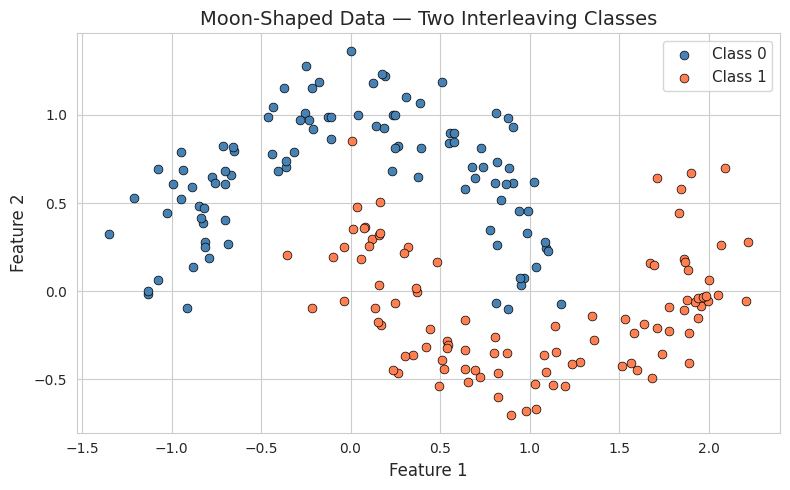

In [9]:
# Generate 200 data points using make_moons(n_samples=200, noise=0.15, random_state=42)
X_moons , y_moons = make_moons(n_samples=200, noise = 0.15, random_state= 42)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1],
            color='steelblue', s=40, label='Class 0', edgecolors='k', linewidth=0.5)
plt.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1],
            color='coral', s=40, label='Class 1', edgecolors='k', linewidth=0.5)
plt.title('Moon-Shaped Data — Two Interleaving Classes', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


### 6.2 Fitting SVM and Visualizing the Decision Boundary

Now let us fit an SVM with different kernels (linear and RBF) and visualize the decision boundary each one creates. This is the best way to understand the difference between kernels.

To visualize a 2D decision boundary, we create a fine mesh grid covering the data range, predict the class at every grid point, and then plot the result as a colored background.

**Task:** Write a helper function to plot decision boundaries, then fit and compare linear vs RBF kernels.

In [10]:
def plot_decision_boundary(model, X, y, ax, title):
    """Plot the decision boundary of a 2D classifier."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], color='steelblue', s=30,
               edgecolors='k', linewidth=0.5, label='Class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='coral', s=30,
               edgecolors='k', linewidth=0.5, label='Class 1')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)


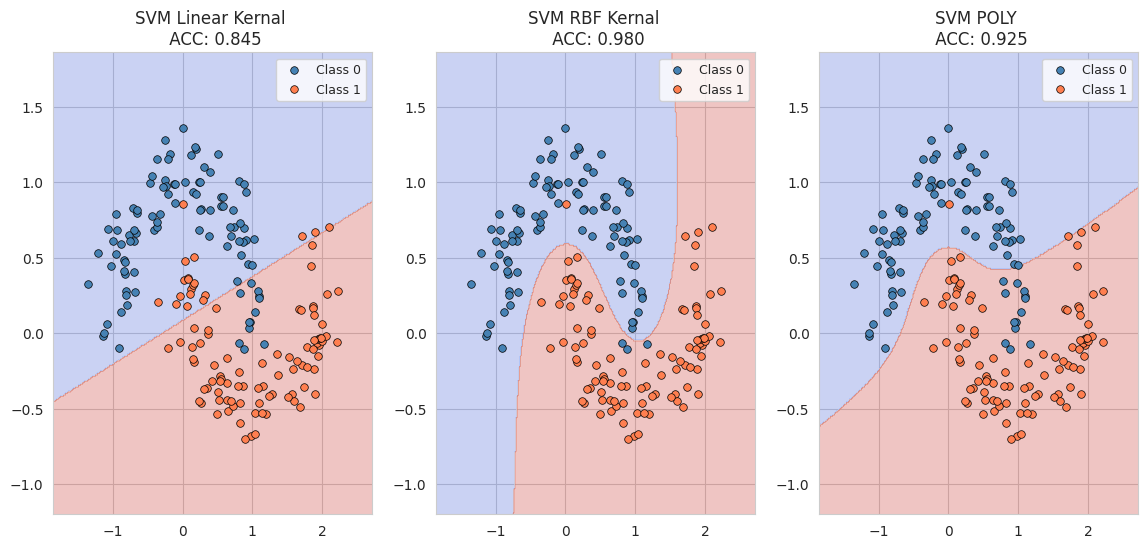

In [19]:
# Create a figure with 1 row, 2 columns, figsize=(14, 5)
fig, axes = plt.subplots(1,3, figsize = (14,6))

# Fit SVC(kernel='linear') on the moon data
# Plot decision boundary in the first subplot
# Title: 'SVM — Linear Kernel'

svm_linear = SVC(kernel= 'linear', C = 1.0)
svm_linear.fit(X_moons, y_moons)
plot_decision_boundary(svm_linear, X_moons, y_moons, axes[0], f"SVM Linear Kernal \n ACC: {svm_linear.score(X_moons, y_moons):.3f}")

# Fit SVC(kernel='rbf') on the moon data
# Plot decision boundary in the second subplot
# Title: 'SVM — RBF Kernel'

svm_rbf = SVC(kernel= 'rbf', C = 1.0)
svm_rbf.fit(X_moons, y_moons)
plot_decision_boundary(svm_rbf, X_moons, y_moons, axes[1], f"SVM RBF Kernal \n ACC: {svm_rbf.score(X_moons, y_moons):.3f}")

svm_poly = SVC(kernel= 'poly', C = 1.0)
svm_poly.fit(X_moons, y_moons)
plot_decision_boundary(svm_poly, X_moons, y_moons, axes[2], f"SVM POLY \n ACC: {svm_poly.score(X_moons, y_moons):.3f}")


# Use plt.tight_layout() and plt.show()


**What to observe:** The linear kernel creates a straight boundary — it does its best but cannot fully separate the curved moon shapes. The RBF kernel creates a smooth, curved boundary that follows the natural shape of the data. This is the power of the kernel trick.

### 6.3 Effect of C on the Decision Boundary

Now let us see how the regularization parameter C affects the decision boundary. We will fit three RBF SVMs with different C values and compare.

**Task:** Fit SVM with C=0.1, C=1.0, and C=100 and plot all three boundaries.

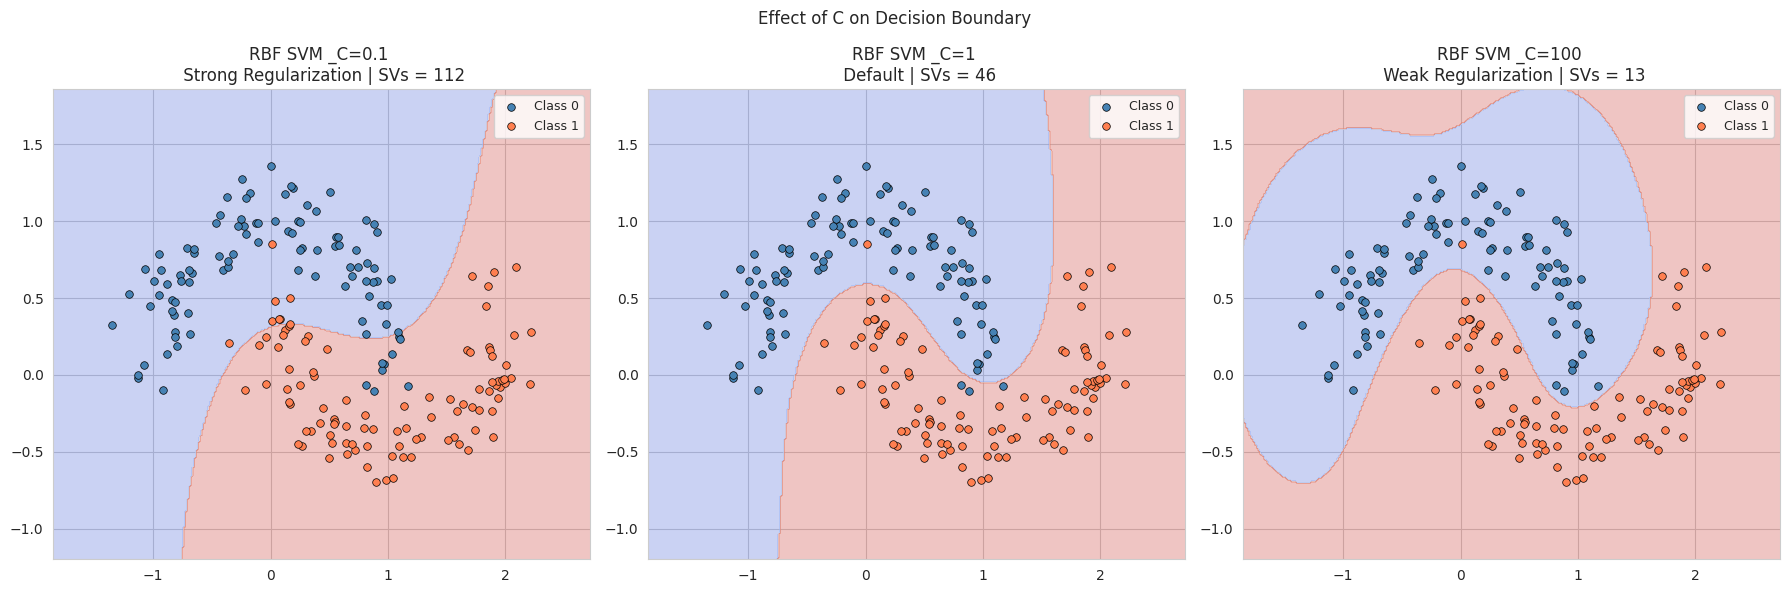

In [22]:
# Create a figure with 1 row, 3 columns, figsize=(18, 5)
fig, axes = plt.subplots(1, 3, figsize = (18,6))
c_value = [0.1, 1, 100]
c_labels = ["Strong Regularization", "Default", "Weak Regularization"]
# For each C in [0.1, 1.0, 100]:
#   Fit SVC(kernel='rbf', C=C)
#   Plot decision boundary
#   Title: e.g., 'RBF SVM — C=0.1 (Smooth boundary)'

for i , (c, label) in enumerate(zip(c_value, c_labels)):
    svm = SVC(kernel='rbf', C = c)
    svm.fit(X_moons, y_moons)
    n_sv = sum(svm.n_support_)
    
    plot_decision_boundary(svm, X_moons, y_moons, axes[i], f'RBF SVM _C={c} \n {label} | SVs = {n_sv}')
    
plt.suptitle("Effect of C on Decision Boundary")
plt.tight_layout()
plt.show()
# Use plt.tight_layout() and plt.show()


**What to observe:**
- **C=0.1 (strong regularization):** The boundary is very smooth. The model tolerates some misclassifications to keep a wide margin. This is a more general, less overfit boundary.
- **C=1.0 (default):** A balanced boundary — reasonably smooth while classifying most points correctly.
- **C=100 (weak regularization):** The boundary becomes more complex, potentially wrapping around individual points to classify them correctly. This risks overfitting.

### 6.4 Effect of Gamma on the Decision Boundary

Now let us fix C and vary gamma to see how the RBF kernel's reach affects the boundary.

**Task:** Fit SVM with gamma=0.1, gamma=1.0, and gamma=10 and plot all three.

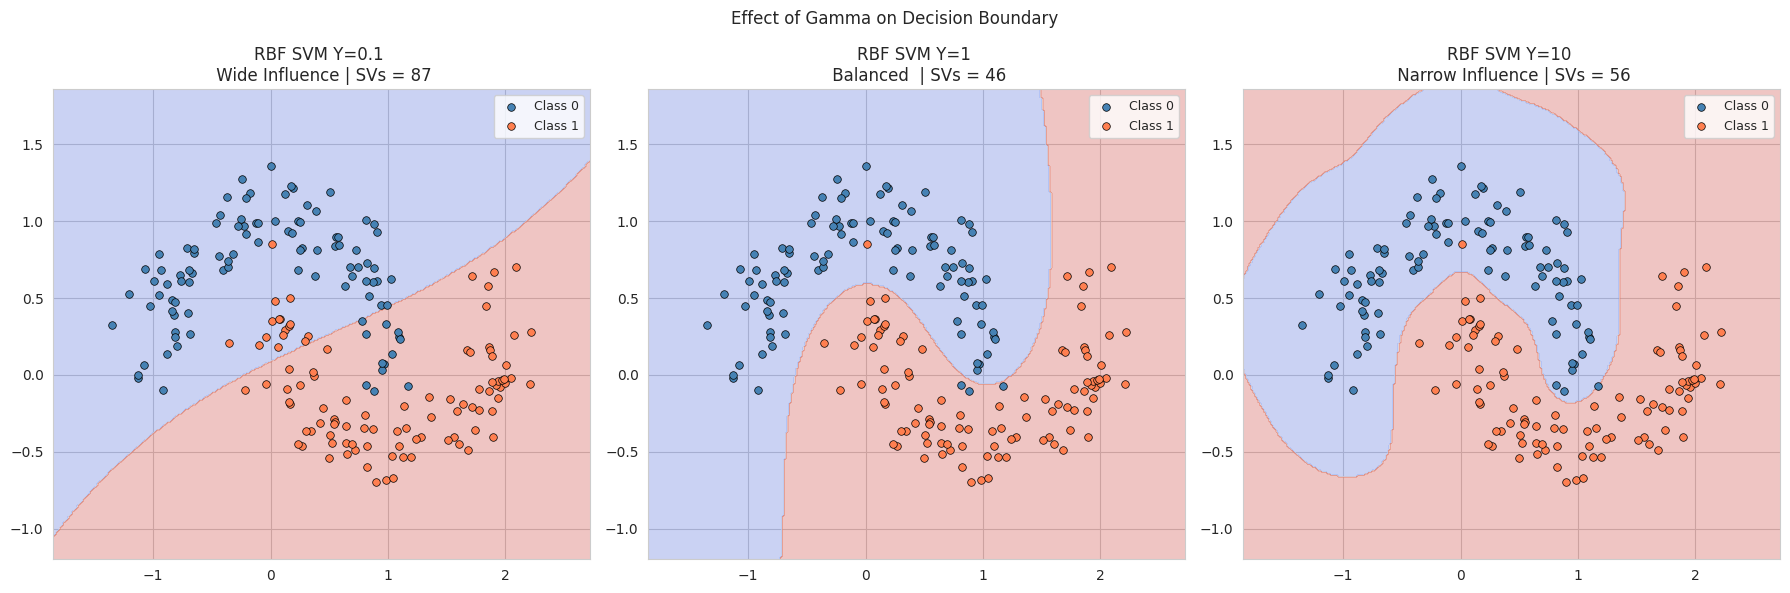

In [23]:
# Create a figure with 1 row, 3 columns, figsize=(18, 5)
fig, axes = plt.subplots(1, 3, figsize = (18,6))
gamma_value = [0.1, 1, 10]
gamma_labels = ["Wide Influence", "Balanced ", "Narrow Influence"]
# For each C in [0.1, 1.0, 100]:
#   Fit SVC(kernel='rbf', C=C)
#   Plot decision boundary
#   Title: e.g., 'RBF SVM — C=0.1 (Smooth boundary)'

for i , (gamma, label) in enumerate(zip(gamma_value, gamma_labels)):
    svm = SVC(kernel='rbf', C = 1.0, gamma= gamma)
    svm.fit(X_moons, y_moons)
    n_sv = sum(svm.n_support_)
    
    plot_decision_boundary(svm, X_moons, y_moons, axes[i], f'RBF SVM Y={gamma} \n {label} | SVs = {n_sv}')
    
plt.suptitle("Effect of Gamma on Decision Boundary")
plt.tight_layout()
plt.show()
# Use plt.tight_layout() and plt.show()


**What to observe:**
- **gamma=0.1 (low):** Each point has a wide influence → the boundary is very smooth and general.
- **gamma=1.0 (medium):** Balanced — the boundary follows the data shape without excessive detail.
- **gamma=10 (high):** Each point has a narrow influence → the boundary becomes very complex, tightly wrapping around individual points. This is classic overfitting.


## 7. SVM on a Real Dataset — Breast Cancer Classification

Now let us apply SVM to the Breast Cancer Wisconsin dataset — the same dataset we used in Day 48 for Logistic Regression. This will let us directly compare SVM's performance against what we achieved with Logistic Regression.

### 7.1 Load and Prepare the Data

**Important:** SVM is very sensitive to feature scales. If one feature ranges from 0 to 1 and another from 0 to 1000, the model will be dominated by the larger feature. We **must** scale the data with StandardScaler before training.

**Task:** Load the data, split it, and scale the features.

In [24]:
# Load the Breast Cancer dataset (as_frame=True)
# Separate X and y
# Split into train/test (test_size=0.2, random_state=42, stratify=y)
# Scale using StandardScaler (fit on train, transform both)
# Print the shapes and class distribution

cancer = load_breast_cancer(as_frame= True)

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test =  train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
x_test_sc = scaler.transform(X_test)

In [28]:
print(f"Breast Cancer Dataset loaded")
print(f"  Training set: {X_train_sc.shape[0]} samples, {X_train_sc.shape[1]} features")
print(f"  Test set:     {x_test_sc.shape[0]} samples")
print(f"  Classes: 0=Malignant ({(y_train == 0).sum()} train), 1=Benign ({(y_train == 1).sum()} train)")

Breast Cancer Dataset loaded
  Training set: 455 samples, 30 features
  Test set:     114 samples
  Classes: 0=Malignant (170 train), 1=Benign (285 train)


### 7.2 Training the SVM Model

We start with the default RBF kernel SVM. We set `probability=True` so we can later compute ROC-AUC — by default, SVM only outputs class labels, not probabilities. Enabling probability estimation uses Platt scaling internally, which adds some computation time but is necessary for AUC evaluation.

We also set `gamma='scale'`, which is the default in modern Scikit-learn. It computes gamma as $\frac{1}{n_{features} \times \text{Var}(X)}$, which adapts to the data's dimensionality and spread.

**Task:** Train an SVM with RBF kernel on the scaled training data.

In [29]:
# Create an SVC model with kernel='rbf', C=1.0, gamma='scale',
# probability=True, random_state=42

# Fit on the scaled training data

# Print confirmation and the number of support vectors
# Hint: model.n_support_ gives the count per class

svm_model = SVC(kernel='rbf', C= 1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_sc, y_train)


print("SVM Model Training Complete!")
print(f"  Kernel:           {svm_model.kernel}")
print(f"  C:                {svm_model.C}")
print(f"  Gamma:            {svm_model.gamma}")
print(f"  Support Vectors:  {sum(svm_model.n_support_)} total")
print(f"    Class 0 (Malignant): {svm_model.n_support_[0]} support vectors")
print(f"    Class 1 (Benign):    {svm_model.n_support_[1]} support vectors")
print(f"  Training samples: {X_train_sc.shape[0]}")
print(f"  SV ratio:         {sum(svm_model.n_support_) / X_train_sc.shape[0]:.1%} of training data")


SVM Model Training Complete!
  Kernel:           rbf
  C:                1.0
  Gamma:            scale
  Support Vectors:  97 total
    Class 0 (Malignant): 51 support vectors
    Class 1 (Benign):    46 support vectors
  Training samples: 455
  SV ratio:         21.3% of training data


**What to observe:** Check the number of support vectors. Remember — only these points determine the decision boundary. If the number is very close to the total number of training samples, the model might be struggling (every point is critical). If it is a small fraction, the model has identified the key boundary points efficiently.

### 7.3 Making Predictions

**Task:** Generate predictions and predicted probabilities on the test set.

In [31]:
# Predict class labels on the scaled test set

# Predict probabilities on the scaled test set

# Display first 10 predictions vs actuals
# Include: Actual, Predicted, P(Malignant), P(Benign)
y_pred = svm_model.predict(x_test_sc)
y_proba = svm_model.predict_proba(x_test_sc)


comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'P(Malignant)': y_proba[:10, 0].round(4),
    'P(Benign)': y_proba[:10, 1].round(4),
    'Correct': ['✓' if a == p else '✗' for a, p in zip(y_test.values[:10], y_pred[:10])]
})

print("First 10 Predictions:")
print(comparison.to_string(index=False))


First 10 Predictions:
 Actual  Predicted  P(Malignant)  P(Benign) Correct
      0          0        0.9986     0.0014       ✓
      1          1        0.0000     1.0000       ✓
      0          0        0.9913     0.0087       ✓
      1          1        0.4365     0.5635       ✓
      0          0        0.9938     0.0062       ✓
      1          1        0.0092     0.9908       ✓
      1          1        0.0000     1.0000       ✓
      0          0        0.9995     0.0005       ✓
      0          0        0.9999     0.0001       ✓
      0          0        0.9777     0.0223       ✓



## 8. Model Evaluation

We will use the same evaluation metrics from Day 48 so we can compare SVM directly against Logistic Regression.

### 8.1 Accuracy

**Task:** Compute the accuracy on the test set.

In [32]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print as percentage
print("Test Accuracy", accuracy)


Test Accuracy 0.9824561403508771


### 8.2 Confusion Matrix

**Task:** Compute and visualize the confusion matrix.

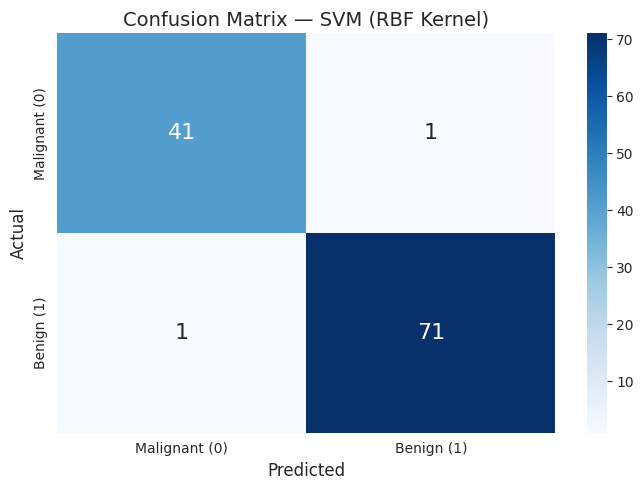

True Negatives  (TN): 41  — Correctly identified Malignant
False Positives (FP): 1  — Predicted Benign, was actually Malignant
False Negatives (FN): 1  — Predicted Malignant, was actually Benign
True Positives  (TP): 71  — Correctly identified Benign


In [33]:
# Compute confusion matrix

# Visualize with sns.heatmap, figsize=(7, 5)
# Use annot=True, fmt='d', cmap='Blues'
# Set labels: ['Malignant (0)', 'Benign (1)']
# Add title: 'Confusion Matrix — SVM (RBF)'
# Show the plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'],
            annot_kws={'size': 16})
plt.title('Confusion Matrix — SVM (RBF Kernel)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — Correctly identified Malignant")
print(f"False Positives (FP): {fp}  — Predicted Benign, was actually Malignant")
print(f"False Negatives (FN): {fn}  — Predicted Malignant, was actually Benign")
print(f"True Positives  (TP): {tp}  — Correctly identified Benign")


### 8.3 Classification Report

**Task:** Print the full classification report.

In [34]:
# Print classification_report with target_names=['Malignant (0)', 'Benign (1)']
print(classification_report(y_test, y_pred, target_names=['Malignant[0]', 'Benign [1]']))


              precision    recall  f1-score   support

Malignant[0]       0.98      0.98      0.98        42
  Benign [1]       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### 8.4 ROC Curve and AUC

**Task:** Plot the ROC curve and compute the AUC score.

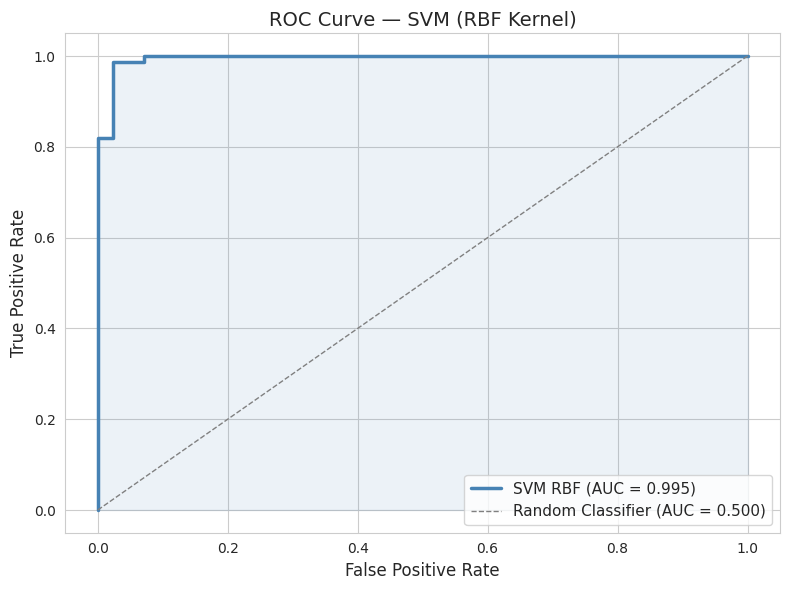

AUC Score: 0.9950


In [35]:
# Get predicted probabilities for the positive class (class 1)

# Compute ROC curve: fpr, tpr, thresholds

# Compute AUC score

# Plot the ROC curve with figsize=(8, 6)
# Include AUC in the label
# Plot the diagonal baseline
# Add title, labels, legend
# Show the plot

y_prob = y_proba[:, 1]
fpr, tpr, theresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'SVM RBF (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1,
         label='Random Classifier (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

plt.title('ROC Curve — SVM (RBF Kernel)', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")


## 9. Comparing SVM Kernels on the Same Data

Let us fit SVM with different kernels (linear, RBF, polynomial) on the Breast Cancer data and compare their performance. This will show you when each kernel is appropriate.

**Task:** Fit three SVM models with different kernels and compare.

In [36]:
# Define a dictionary of kernels to try:
# 'Linear': SVC(kernel='linear', C=1.0, probability=True, random_state=42)
# 'RBF': SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
# 'Polynomial (d=3)': SVC(kernel='poly', degree=3, C=1.0, probability=True, random_state=42)

# For each kernel:
#   Fit on scaled training data
#   Compute test accuracy
#   Compute AUC score
#   Count support vectors: sum(model.n_support_)

# Display results as a neat table


kernels = {
    'Linear': SVC(kernel='linear', C=1.0, probability=True, random_state=42),
    'RBF': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Polynomial (d=3)': SVC(kernel='poly', degree=3, C=1.0, probability=True, random_state=42)
}

kernel_results = []

for name, model in kernels.items():
    model.fit(X_train_sc, y_train)
    y_p = model.predict(x_test_sc)
    y_prob_k = model.predict_proba(x_test_sc)[:, 1]

    acc = accuracy_score(y_test, y_p)
    auc_k = roc_auc_score(y_test, y_prob_k)
    n_sv = sum(model.n_support_)

    kernel_results.append({
        'Kernel': name,
        'Test Accuracy': round(acc, 4),
        'AUC Score': round(auc_k, 4),
        'Support Vectors': n_sv,
        'SV Ratio': f"{n_sv / X_train_sc.shape[0]:.1%}"
    })

kernel_df = pd.DataFrame(kernel_results)
print("=" * 70)
print("  KERNEL COMPARISON — Breast Cancer Dataset")
print("=" * 70)
print(kernel_df.to_string(index=False))
print("=" * 70)


  KERNEL COMPARISON — Breast Cancer Dataset
          Kernel  Test Accuracy  AUC Score  Support Vectors SV Ratio
          Linear         0.9737     0.9964               32     7.0%
             RBF         0.9825     0.9950               97    21.3%
Polynomial (d=3)         0.9123     0.9954              145    31.9%


**What to observe:** For this particular dataset, all three kernels should perform well because the data is roughly linearly separable (we saw this in Day 48). The linear kernel is simplest and fastest. RBF is more flexible. The polynomial kernel adds complexity that may or may not help. Check which has the fewest support vectors — fewer support vectors generally means a more efficient model.


## 10. Effect of C — Regularization Experiment

Let us systematically explore how the C parameter affects SVM performance on the Breast Cancer data. We will sweep through several C values and track training accuracy, test accuracy, and the number of support vectors.

**Task:** Fit RBF SVM at different C values and create a comparison.

In [38]:
# Try C values: [0.01, 0.1, 1.0, 10, 100]

# For each C:
#   Fit SVC(kernel='rbf', C=C, probability=True, random_state=42)
#   Compute train accuracy, test accuracy
#   Count total support vectors
#   Print results in a neat table

# After the table, print observations:
# Which C has the best test accuracy?
# How does the train-test gap change with C?
# How does the number of support vectors change?


c_values = [0.01, 0.1, 1.0, 10, 100]

print(f"{'C':<8} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'Sup. Vectors':>14} {'SV Ratio':>10}")
print("-" * 64)

for c in c_values:
    svm = SVC(kernel='rbf', C=c, probability=True, random_state=42)
    svm.fit(X_train_sc, y_train)

    train_acc = accuracy_score(y_train, svm.predict(X_train_sc))
    test_acc = accuracy_score(y_test, svm.predict(x_test_sc))
    gap = train_acc - test_acc
    n_sv = sum(svm.n_support_)
    sv_ratio = n_sv / X_train_sc.shape[0]

    print(f"{c:<8} {train_acc:>10.4f} {test_acc:>10.4f} {gap:>8.4f} {n_sv:>14} {sv_ratio:>10.1%}")

print("\nObservations:")
print("  → As C increases: training accuracy ↑, gap may widen, support vectors ↓")
print("  → The sweet spot balances test accuracy with a small train-test gap")


C         Train Acc   Test Acc      Gap   Sup. Vectors   SV Ratio
----------------------------------------------------------------
0.01         0.6264     0.6316  -0.0052            341      74.9%
0.1          0.9582     0.9474   0.0109            199      43.7%
1.0          0.9824     0.9825  -0.0000             97      21.3%
10           0.9934     0.9737   0.0197             84      18.5%
100          1.0000     0.9474   0.0526             64      14.1%

Observations:
  → As C increases: training accuracy ↑, gap may widen, support vectors ↓
  → The sweet spot balances test accuracy with a small train-test gap


**What to observe:**
- At small C, the model is heavily regularized — it may underfit (lower accuracy, but train and test are close)
- At large C, the model fits the training data more tightly — training accuracy goes up but the gap with test accuracy may widen
- The number of support vectors typically **decreases** as C increases (the model relies on fewer, more critical points)
- The sweet spot for C balances accuracy and generalization



## 11. Train vs Test Performance

As always, let us compare the model's performance on training data versus test data to check for overfitting.

**Task:** Compute and compare train vs test accuracy and AUC for the best SVM model.

In [39]:
# Use the default RBF model (C=1.0) we trained earlier

# Predict on training set

# Compute training accuracy and AUC

# Compute test accuracy and AUC (we already have these)

# Print both side by side

# Interpret: overfitting, underfitting, or good fit?


y_train_pred = svm_model.predict(X_train_sc)
y_train_proba = svm_model.predict_proba(X_train_sc)[:, 1]

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("  TRAIN vs TEST — SVM (RBF, C=1.0)")
print("=" * 50)
print(f"  {'Metric':<12} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*10}")
print(f"  {'Accuracy':<12} {train_acc:>10.4f} {test_acc:>10.4f} {train_acc - test_acc:>10.4f}")
print(f"  {'AUC':<12} {train_auc:>10.4f} {test_auc:>10.4f} {train_auc - test_auc:>10.4f}")
print("=" * 50)

gap = train_acc - test_acc
if gap < 0.03:
    print("\n  → Scores are very close. The model generalizes well.")
elif gap < 0.10:
    print("\n  → Some gap. Mild overfitting possible.")
else:
    print("\n  → Large gap. The model is likely overfitting.")


  TRAIN vs TEST — SVM (RBF, C=1.0)
  Metric            Train       Test        Gap
  ------------ ---------- ---------- ----------
  Accuracy         0.9824     0.9825    -0.0000
  AUC              0.9980     0.9950     0.0030

  → Scores are very close. The model generalizes well.




## 12. SVM vs Logistic Regression — Head-to-Head Comparison

Since we trained Logistic Regression on the same dataset in Day 48, let us do a direct head-to-head comparison. We will train both models here and compare all metrics.

**Task:** Train both models and compare their performance.

In [40]:
# Import LogisticRegression

# Train LogisticRegression(random_state=42, max_iter=5000) on scaled data

# Train SVC(kernel='rbf', C=1.0, probability=True, random_state=42) on scaled data

# For each model, compute: test accuracy, AUC

# Display comparison in a neat table
# Include: Model name, Test Accuracy, AUC Score
from sklearn.linear_model import LogisticRegression

# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=5000)
lr_model.fit(X_train_sc, y_train)
lr_pred = lr_model.predict(x_test_sc)
lr_prob = lr_model.predict_proba(x_test_sc)[:, 1]
lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

# SVM (RBF)
svm_acc = accuracy_score(y_test, y_pred)
svm_auc = roc_auc_score(y_test, y_prob)

# SVM (Linear)
svm_lin = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_lin.fit(X_train_sc, y_train)
svm_lin_pred = svm_lin.predict(x_test_sc)
svm_lin_prob = svm_lin.predict_proba(x_test_sc)[:, 1]
svm_lin_acc = accuracy_score(y_test, svm_lin_pred)
svm_lin_auc = roc_auc_score(y_test, svm_lin_prob)

print("=" * 55)
print("  HEAD-TO-HEAD COMPARISON")
print("=" * 55)
print(f"  {'Model':<25} {'Accuracy':>10} {'AUC':>10}")
print(f"  {'-'*25} {'-'*10} {'-'*10}")
print(f"  {'Logistic Regression':<25} {lr_acc:>10.4f} {lr_auc:>10.4f}")
print(f"  {'SVM (Linear)':<25} {svm_lin_acc:>10.4f} {svm_lin_auc:>10.4f}")
print(f"  {'SVM (RBF)':<25} {svm_acc:>10.4f} {svm_auc:>10.4f}")
print("=" * 55)



  HEAD-TO-HEAD COMPARISON
  Model                       Accuracy        AUC
  ------------------------- ---------- ----------
  Logistic Regression           0.9825     0.9954
  SVM (Linear)                  0.9737     0.9964
  SVM (RBF)                     0.9825     0.9950


**What to observe:** For this dataset, both models should perform very well. The results are often very close, which is expected — the Breast Cancer dataset is roughly linearly separable, so both a linear model (Logistic Regression) and a non-linear one (RBF SVM) can handle it effectively. The real advantage of SVM shows up on datasets with complex, non-linear boundaries.
